# Sesión 7: Random Forest vs. Gradient Boosting

**Objetivos:**
-   Visualizar y entender las filosofías de **Bagging (Random Forest)** y **Boosting (Gradient Boosting)**.
-   Conocer y razonar sobre los **hiperparámetros clave** de cada modelo.
-   Realizar una **comparativa práctica** de rendimiento, tiempo de entrenamiento e interpretabilidad.
-   Optimizar el mejor modelo y reflexionar sobre los trade-offs de negocio.

## 1. Random Forest: La Fuerza de la Aleatoriedad y el Paralelismo

El **Random Forest** combate la inestabilidad de un solo árbol mediante la creación de un "bosque" de árboles diversos y promediando sus resultados. Su estrategia se llama **Bagging (Bootstrap Aggregating)**.

-   **Pros:**
    -   ✔️ Muy **robusto** al sobreajuste.
    -   ✔️ **Fácil de paralelizar** (cada árbol se entrena de forma independiente), lo que lo hace eficiente en CPUs con múltiples núcleos.
    -   ✔️ Requiere **poco ajuste fino** para obtener un buen resultado inicial. Es un modelo excelente como punto de partida.
-   **Contras:**
    -   ❌ Menos **interpretable** que un solo árbol. Ya no podemos visualizar una única estructura de decisiones.
    -   ❌ Puede ser **lento para hacer predicciones** si el número de árboles (`n_estimators`) es muy grande.

### Hiperparámetros Clave (`RandomForestRegressor`):
-   `n_estimators`: El número de árboles en el bosque. Es el más importante. Más árboles suelen mejorar el rendimiento, pero con rendimientos decrecientes y a un mayor coste computacional.
-   `max_depth`, `min_samples_leaf`: Idénticos a los de un árbol simple, controlan la complejidad de cada árbol individual en el bosque.
-   `max_features`: El número de características que cada árbol puede considerar en cada división. Limitar esto aumenta la diversidad de los árboles y reduce la varianza del modelo final.

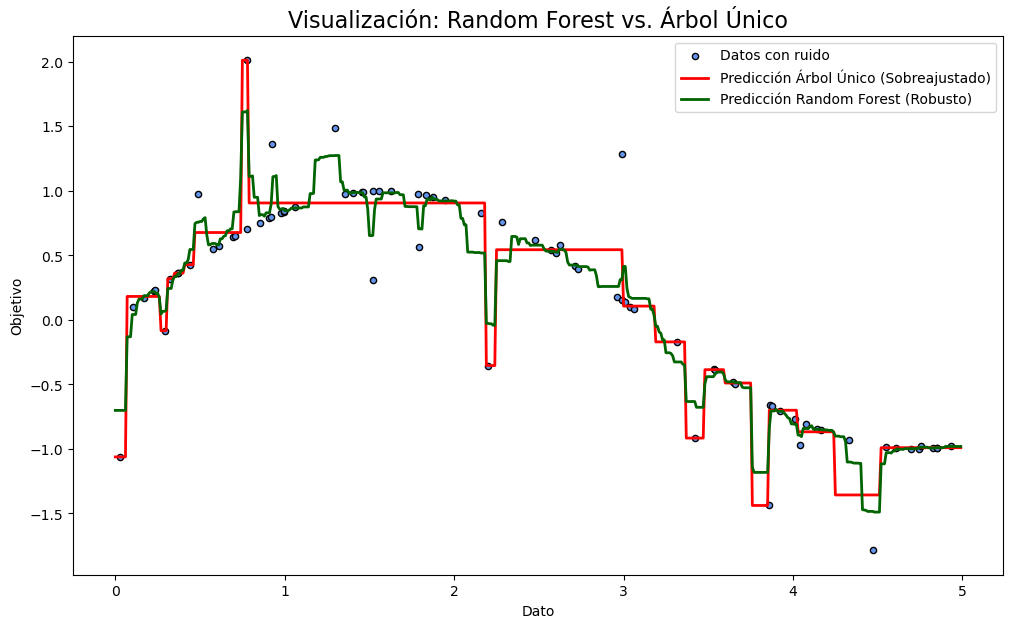

In [12]:
# --- Celda de configuración y visualización de Bagging ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Creamos un dataset de juguete (una curva seno con ruido)
rng = np.random.RandomState(42)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16)) # Añadimos ruido

# 2. Entrenamos un árbol de decisión muy profundo (que sobreajustará)
tree = DecisionTreeRegressor(max_depth=5)
tree.fit(X, y)

# 3. Entrenamos un Random Forest sobre los mismos datos
forest = RandomForestRegressor(n_estimators=100, random_state=42)
forest.fit(X, y)

# 4. Preparamos datos para dibujar las curvas de predicción
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_tree = tree.predict(X_test)
y_forest = forest.predict(X_test)

# 5. Visualizamos
plt.figure(figsize=(12, 7))
plt.scatter(X, y, s=20, edgecolor="black", c="cornflowerblue", label="Datos con ruido")
plt.plot(X_test, y_tree, color="red", label="Predicción Árbol Único (Sobreajustado)", linewidth=2)
plt.plot(X_test, y_forest, color="darkgreen", label="Predicción Random Forest (Robusto)", linewidth=2)
plt.xlabel("Dato")
plt.ylabel("Objetivo")
plt.title("Visualización: Random Forest vs. Árbol Único", fontsize=16)
plt.legend()
plt.show()

# Conclusión visual: La línea roja (árbol único) se adapta de forma agresiva a cada punto,
# incluso al ruido. La línea verde (Random Forest) captura la tendencia general de los
# datos de forma mucho más suave y robusta.

### Conclusión Visual: La Magia de Promediar

Este gráfico es una demostración perfecta de por qué funciona el **Random Forest**.

* **Los Datos (Puntos Azules)**: Representan nuestra "realidad". Siguen una tendencia general (una curva suave), pero tienen mucho **ruido**, es decir, variaciones aleatorias que no forman parte del patrón real.

* **El Árbol Único (Línea Roja)**: Este es un árbol de decisión profundo y sin restricciones. Como es tan flexible, intenta ser "perfecto" y se esfuerza por pasar por cada punto de dato individual. El resultado es que **"memoriza" el ruido** en lugar de aprender la tendencia subyacente. Esta línea dentada y quebrada es la representación visual del **sobreajuste (overfitting)**. Un modelo así sería terrible para predecir nuevos datos.

* **El Random Forest (Línea Verde)**: Este modelo entrena cientos de árboles como el rojo, pero cada uno sobre una muestra ligeramente diferente de los datos. Luego, promedia todas sus predicciones. Al hacer esto, los errores y las "memorizaciones" aleatorias de cada árbol individual **se cancelan entre sí**. El resultado es una predicción mucho más suave y robusta que ignora el ruido y captura la **verdadera señal** de los datos.

**En resumen:** La línea verde es más "sabia" porque se basa en el consenso de un comité de árboles, mientras que la línea roja es la opinión de un único "experto" inestable. Esta es la esencia del Bagging: reducir el error promediando muchos modelos.

## 2. Gradient Boosting: La Fuerza de la Colaboración Secuencial

El **Gradient Boosting** construye los árboles uno tras otro, de forma secuencial. Cada nuevo árbol se entrena para **corregir los errores** cometidos por el conjunto de árboles anteriores.

-   **Pros:**
    -   🚀 A menudo, alcanza un **rendimiento superior** al de Random Forest, especialmente en datasets bien estructurados.
    -   Ofrece mucho **control** a través de sus hiperparámetros.
-   **Contras:**
    -   ❌ Más **propenso al sobreajuste** si no se controla bien. Un `learning_rate` alto o demasiados `n_estimators` pueden hacer que "memorice" el ruido.
    -   ❌ El entrenamiento es **secuencial**, por lo que no se puede paralelizar de la misma manera que un Random Forest.

### Hiperparámetros Clave (`GradientBoostingRegressor`):
-   `n_estimators`: Número de árboles que se entrenan en secuencia.
-   `learning_rate` (Tasa de Aprendizaje): El más importante junto con `n_estimators`. Controla el peso o la contribución de cada árbol al resultado final. **Valores más bajos requieren más árboles para un buen rendimiento, pero resultan en modelos más robustos.**
-   `max_depth`, `min_samples_split`: Controlan la complejidad de cada árbol individual, que en Gradient Boosting suelen ser "débiles" (poco profundos).

### 💡 BONUS: Más Allá de Scikit-learn
En la industria, para problemas de Gradient Boosting, es muy común usar librerías especializadas aún más potentes y rápidas, como **XGBoost**, **LightGBM** o **CatBoost**. `scikit-learn` también tiene una implementación muy rápida llamada `HistGradientBoostingRegressor` que vale la pena explorar.

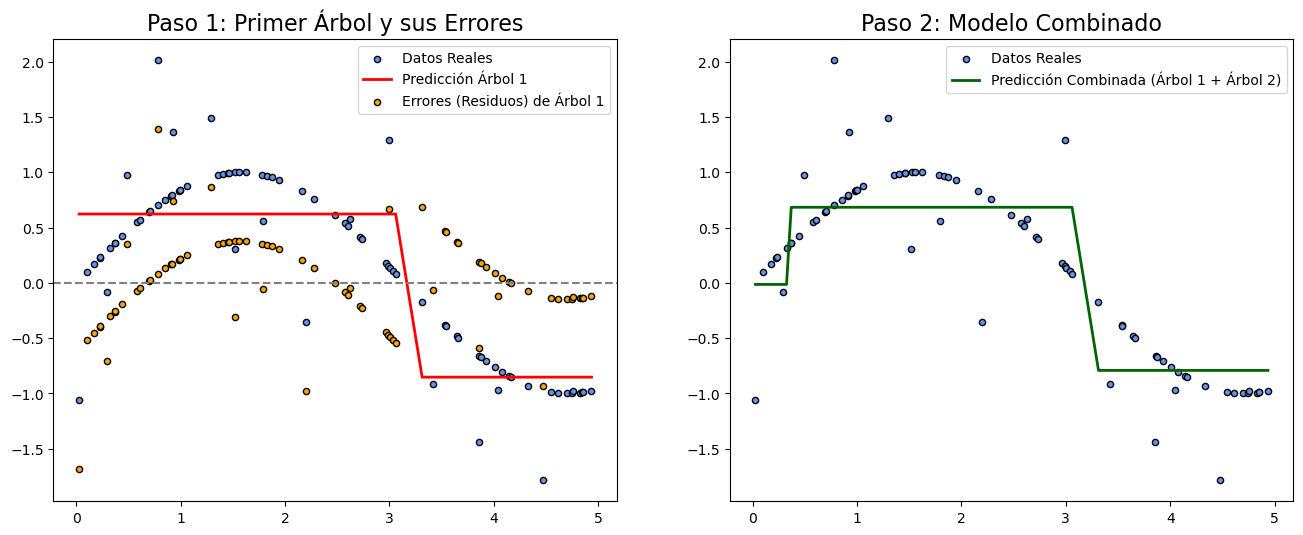

In [13]:
# --- Celda de visualización de Boosting ---

# 1. Usamos los mismos datos de juguete (X, y)
# 2. Entrenamos un primer árbol muy débil (profundidad 1)
tree_1 = DecisionTreeRegressor(max_depth=1, random_state=42)
tree_1.fit(X, y)
y_pred_1 = tree_1.predict(X)

# 3. Calculamos los errores (residuos) del primer árbol
residuals_1 = y - y_pred_1

# 4. Entrenamos un segundo árbol para que aprenda a predecir esos errores
tree_2 = DecisionTreeRegressor(max_depth=1, random_state=42)
tree_2.fit(X, residuals_1)
y_pred_2 = tree_2.predict(X)

# 5. La predicción final (simplificada) es la suma de la predicción del primer árbol más la corrección del segundo
y_pred_final = y_pred_1 + y_pred_2

# 6. Visualizamos el proceso
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# Gráfico 1: Primer árbol y sus errores
ax1.scatter(X, y, s=20, edgecolor="black", c="cornflowerblue", label="Datos Reales")
ax1.plot(X, y_pred_1, color="red", label="Predicción Árbol 1", linewidth=2)
ax1.scatter(X, residuals_1, s=20, edgecolor="black", c="orange", label="Errores (Residuos) de Árbol 1")
ax1.axhline(0, color='gray', linestyle='--')
ax1.set_title("Paso 1: Primer Árbol y sus Errores", fontsize=16)
ax1.legend()

# Gráfico 2: El resultado final
ax2.scatter(X, y, s=20, edgecolor="black", c="cornflowerblue", label="Datos Reales")
ax2.plot(X, y_pred_final, color="darkgreen", label="Predicción Combinada (Árbol 1 + Árbol 2)", linewidth=2)
ax2.set_title("Paso 2: Modelo Combinado", fontsize=16)
ax2.legend()
plt.show()

### Conclusión Visual: La Fuerza de Corregir Errores

Este par de gráficos revela la estrategia "colaborativa" del **Gradient Boosting**. En lugar de promediar, los árboles trabajan en equipo y de forma secuencial.



#### **Paso 1: Primer Árbol y sus Errores (Gráfico Izquierdo)**
* **Datos Reales (Puntos Azules)**: Nuestra "realidad" con su tendencia y su ruido.
* **Predicción Árbol 1 (Línea Roja)**: Entrenamos un árbol muy "débil" y simple (de profundidad 1). Como se puede ver, su predicción es muy tosca y no se ajusta bien a los datos. Es un modelo con un error alto.
* **Errores o Residuos (Puntos Naranjas)**: Estos puntos representan la **diferencia** entre los datos reales y la predicción del primer árbol. Son, literalmente, los fallos del primer modelo. Fíjate en que los errores no son aleatorios; tienen una estructura clara.

#### **Paso 2: Modelo Combinado (Gráfico Derecho)**
* **El truco del Boosting**: Se entrena un segundo árbol, pero su objetivo no es predecir los datos originales, sino **predecir los errores** (los puntos naranjas) del primer árbol.
* **Predicción Combinada (Línea Verde)**: Esta línea es la suma de la predicción del primer árbol **más** la predicción del segundo árbol (que corrige los errores del primero). El resultado es un modelo mucho más preciso y que se ajusta mejor a la tendencia real de los datos.

**En resumen:** Gradient Boosting construye un modelo por etapas. Cada nuevo árbol que se añade al ensamblado no trabaja por su cuenta, sino que se enfoca en solucionar los problemas que los árboles anteriores no pudieron resolver. Es un proceso de **mejora continua** que resulta en modelos extremadamente potentes.

---
## 🛠️ EJERCICIO EN CLASE: La Gran Comparativa

Ahora que entendemos la teoría, vamos a enfrentar a los modelos en el dataset de vivienda.

### Tarea 1: Rendimiento vs. Tiempo

1.  **Carga y prepara los datos** de vivienda (numéricos, sin nulos, `train_test_split`).
2.  **Entrena y evalúa los tres modelos** (`DecisionTreeRegressor`, `RandomForestRegressor`, `GradientBoostingRegressor`) con sus parámetros por defecto (`random_state=42`).
3.  Para cada uno, calcula su **RMSE en prueba** y su **tiempo de entrenamiento**.
4.  Muestra los resultados en una **tabla comparativa** de `pandas`.

### Tarea 2: Interpretabilidad

1.  Obtén las `feature_importances_` de los tres modelos.
2.  Crea un **gráfico de barras comparativo** que muestre la importancia que cada modelo le da a cada característica.

### Tarea 3: Experimentación Manual

1.  Entrena un nuevo `GradientBoostingRegressor`, pero esta vez cambia el `learning_rate` a `0.01` (el defecto es 0.1).
2.  Calcula su RMSE. ¿Ha mejorado o empeorado respecto al modelo por defecto?
3.  **Conclusión (en una celda de texto)**: ¿Qué te dice el resultado sobre la relación entre `learning_rate` y `n_estimators`?

##### Tarea 1

In [14]:
#1.  **Carga y prepara los datos** de vivienda (numéricos, sin nulos, `train_test_split`).
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import time


url = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'
df = pd.read_csv(url)

numericos = df.select_dtypes(include=['number'])

for col in numericos.columns:
    if numericos[col].isnull().any():
        median_val = numericos[col].median()
        numericos[col] = numericos[col].fillna(median_val)


# Separar X e y
X = numericos.drop('median_house_value', axis=1)
y = numericos['median_house_value']

# División train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
#2.  **Entrena y evalúa los tres modelos** (`DecisionTreeRegressor`, `RandomForestRegressor`, `GradientBoostingRegressor`) con sus parámetros por defecto (`random_state=42`).
#3.  Para cada uno, calcula su **RMSE en prueba** y su **tiempo de entrenamiento**.
def evaluar_modelo(modelo, nombre, X_train, y_train, X_test, y_test):
    """
    Entrena un modelo, mide su tiempo y calcula el RMSE en prueba.
    
    Parámetros:
    - modelo: Modelo de sklearn sin entrenar
    - nombre: Nombre descriptivo del modelo
    - X_train, y_train: Datos de entrenamiento
    - X_test, y_test: Datos de prueba
    
    Retorna:
    - Diccionario con nombre, RMSE y tiempo de entrenamiento
    """
    # Medir tiempo de entrenamiento
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tiempo_entrenamiento = time.time() - inicio
    
    # Predecir en el conjunto de prueba
    y_pred = modelo.predict(X_test)
    
    # Calcular RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    return {
        'Modelo': nombre,
        'RMSE': round(rmse, 4),
        'Tiempo (segundos)': round(tiempo_entrenamiento, 4)
    }

# --- Modelo 1: Árbol de Decisión Simple ---
tree = DecisionTreeRegressor(random_state=42)
resultado_tree = evaluar_modelo(
    tree, 'Árbol de Decisión', X_train, y_train, X_test, y_test
)

# --- Modelo 2: Random Forest ---
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
resultado_rf = evaluar_modelo(
    rf, 'Random Forest', X_train, y_train, X_test, y_test
)

# --- Modelo 3: Gradient Boosting ---
gb = GradientBoostingRegressor(random_state=42)
resultado_gb = evaluar_modelo(
    gb, 'Gradient Boosting', X_train, y_train, X_test, y_test
)


In [16]:
#4.  Muestra los resultados en una **tabla comparativa** de `pandas`.
resultados = pd.DataFrame([resultado_tree, resultado_rf, resultado_gb])

print("\n" + "="*60)
print("TABLA COMPARATIVA - RENDIMIENTO VS. TIEMPO")
print("="*60)
print(resultados.to_string(index=False))
print("="*60)



TABLA COMPARATIVA - RENDIMIENTO VS. TIEMPO
           Modelo       RMSE  Tiempo (segundos)
Árbol de Decisión 69869.7255             0.3584
    Random Forest 49880.4565             2.8113
Gradient Boosting 55717.1592             6.1579


##### Tarea 2

In [17]:
#1.  Obtén las `feature_importances_` de los tres modelos.


In [18]:
#2.  Crea un **gráfico de barras comparativo** que muestre la importancia que cada modelo le da a cada característica.


##### Tarea 3

In [19]:
#1.  Entrena un nuevo `GradientBoostingRegressor`, pero esta vez cambia el `learning_rate` a `0.01` (el defecto es 0.1).


In [20]:
#2.  Calcula su RMSE. ¿Ha mejorado o empeorado respecto al modelo por defecto?


In [21]:
#3.  **Conclusión (en una celda de texto)**: ¿Qué te dice el resultado sobre la relación entre `learning_rate` y `n_estimators`?


---
## ❓ Preguntas de recap – Sesión 1 (Random Forest)

1. ¿Qué problema de los árboles individuales soluciona el Random Forest?  
2. ¿Qué significa el parámetro `n_estimators`?  
3. ¿Por qué usar “bootstrap samples” mejora la generalización?  
4. ¿Qué aporta la aleatoriedad al construir cada árbol?
---

---
## 🏠 EJERCICIO PARA CASA: Optimizando el Campeón

El `GradientBoostingRegressor` parece muy prometedor, pero sensible a sus hiperparámetros. Tu misión es encontrar la mejor configuración posible usando `GridSearchCV`.

### Tareas:
1.  **Define un `param_grid`** para `GradientBoostingRegressor`:
    * `n_estimators`: `[100, 200]`
    * `learning_rate`: `[0.1, 0.05]`
    * `max_depth`: `[3, 5]`
2.  **Configura y ejecuta `GridSearchCV`** (`cv=3`, `scoring='neg_mean_squared_error'`).
3.  **Muestra los mejores parámetros** y el **RMSE final** del mejor modelo en el conjunto de prueba.

### Preguntas Finales para la Reflexión

1.  **Tabla Comparativa Final**: Crea una tabla comparando el RMSE de todos los modelos que hemos visto para este dataset (Lasso, Árbol simple tuneado, RF por defecto, GB por defecto, y tu nuevo GB tuneado).
2.  **Análisis Coste-Beneficio**: ¿Valió la pena el tiempo de `GridSearchCV`? ¿Cuánto mejoró el rendimiento respecto al GB por defecto?
3.  **Decisión de Despliegue**: Eres el jefe de Data Science. Tienes que elegir un modelo para dos tareas:
    * **Tarea A**: La API pública de valoración en la web de la inmobiliaria (se valora la **precisión** y la **velocidad de predicción**).
    * **Tarea B**: Una herramienta interna para que los agentes inmobiliarios entiendan qué factores suben o bajan el precio de una casa (se valora la **interpretabilidad**).
    
    ¿Qué modelo de todos los que hemos visto en el curso elegirías para cada tarea? Justifica tu doble elección.

In [22]:
# ESPACIO PARA EL EJERCICIO PARA CASA
# TU CÓDIGO AQUÍ

### Mis Reflexiones

*(Escribe aquí tus respuestas a las preguntas del ejercicio para casa)*

---
## ❓ Preguntas de recap – Sesión 2 (Gradient Boosting)

1. ¿En qué se diferencia el Gradient Boosting del Random Forest?  
2. ¿Qué papel cumple la tasa de aprendizaje (`learning_rate`)?  
3. ¿Qué pasa si el número de árboles (`n_estimators`) es muy alto?  
4. ¿Por qué el Gradient Boosting puede sobreajustar más fácilmente?
---